# Corrected Phase 1 - fMRI Music Genre Classification

**Goal:** classify the genre of a 15-second music clip from one participant's whole-brain fMRI response.

This notebook rebuilds Phase 1 from scratch with a leakage-resistant, reproducible workflow:

1. Audit the event files and the preprocessed response arrays.
2. Remove the repeated `onset = 0 s` event from every training run.
3. Construct exactly **40 non-duplicate clips per run × 12 runs = 480 clips per subject**.
4. Keep every feature window strictly inside its own run.
5. Cache clip-level features without keeping all five raw arrays in memory.
6. Evaluate a fixed primary model with **Leave-One-Run-Out cross-validation**.
7. Fit voxel selection and scaling inside each training fold.
8. Save out-of-fold predictions, fold scores, confusion matrices, and summary tables.
9. Optionally run grouped permutation tests and nested hyperparameter tuning.

---

## Important methodological decision

The primary result in this notebook uses an **unshifted 10-TR clip-block average**.

It deliberately does **not** select a subject-specific haemodynamic delay using the same cross-validation scores later reported as final. A delay sweep can be added later only inside a properly nested procedure and with windows that never cross run boundaries.

### Dataset references

- OpenNeuro dataset: `ds003720`
- Derivative response arrays: Zenodo record `8275363`
- Nakai, Koide-Majima, and Nishimoto, *Music genre neuroimaging dataset* (2022)

The OpenNeuro README states that the first training stimulus from `0–15 s` repeats the final stimulus of the previous run. The derivative arrays contain `4800` training volumes, i.e. `12 × 400`, which corresponds to 40 retained 15-second blocks per run.

## 0. Expected folder structure

Place this notebook in the project folder shown below:

```text
FMRI_Classification/
    fmri_classification_corrected_phase1.ipynb
    001/
        sub-001_Resp_Training.npy
        sub-001_task-Training_run-01_events.tsv
        ...
        sub-001_task-Training_run-12_events.tsv
    002/
    003/
    004/
    005/
```

The notebook auto-detects this structure from the current directory. If it cannot find the folders, set `PROJECT_ROOT` manually in the configuration cell.

## 1. Imports and reproducibility settings

In [1]:
# Uncomment once if packages are missing:
# %pip install numpy pandas scipy scikit-learn matplotlib

from __future__ import annotations

import gc
import json
import platform
import sys
import time
import warnings
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn import __version__ as sklearn_version
from sklearn.base import clone
from sklearn.feature_selection import SelectKBest, VarianceThreshold, f_classif
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import (
    GroupKFold,
    GridSearchCV,
    LeaveOneGroupOut,
    permutation_test_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

warnings.filterwarnings("ignore", category=RuntimeWarning)

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

print("Python:", sys.version.split()[0])
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)
print("scikit-learn:", sklearn_version)
print("Platform:", platform.platform())

Python: 3.13.2
NumPy: 2.4.4
pandas: 3.0.3
scikit-learn: 1.8.0
Platform: macOS-26.5-arm64-arm-64bit-Mach-O


## 2. Configuration

In [21]:
# Change only this line if the notebook is not stored in the project folder.
PROJECT_ROOT = Path.cwd().resolve()

SUBJECT_IDS = [f"sub-{i:03d}" for i in range(1, 6)]
SUBJECT_FOLDER = {sid: sid.split("-")[1] for sid in SUBJECT_IDS}

TR_SECONDS = 1.5
CLIP_SECONDS = 15
TRS_PER_CLIP = int(CLIP_SECONDS / TR_SECONDS)   # 10
RUNS_PER_SUBJECT = 12
TRS_PER_RUN = 400
EXPECTED_CLIPS_PER_RUN = 40
EXPECTED_CLIPS_PER_SUBJECT = RUNS_PER_SUBJECT * EXPECTED_CLIPS_PER_RUN

# Fixed primary model: these values are not selected from the reported CV scores.
PRIMARY_K = 1300
PRIMARY_C = 1.0
PRIMARY_KERNEL = "linear"

CACHE_ROOT = PROJECT_ROOT / "cache_corrected_phase1"
OUTPUT_ROOT = PROJECT_ROOT / "outputs_corrected_phase1"
CACHE_ROOT.mkdir(parents=True, exist_ok=True)
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

RUN_PERMUTATION_TESTS = True
N_PERMUTATIONS = 1000

RUN_NESTED_CV = False
NESTED_N_JOBS = 1      # Keep at 1 to avoid duplicating very large arrays in memory.

ALIGNMENT_VERSION = "drop_repeated_onset0_then_map_40x10_blocks_v1"

print("Project root:", PROJECT_ROOT)
print("Cache folder:", CACHE_ROOT)
print("Output folder:", OUTPUT_ROOT)

Project root: /Users/manognya/Downloads/FMRI_Classification
Cache folder: /Users/manognya/Downloads/FMRI_Classification/cache_corrected_phase1
Output folder: /Users/manognya/Downloads/FMRI_Classification/outputs_corrected_phase1


## 3. Locate and validate the project files

In [3]:
def locate_data_root(start: Path) -> Path:
    """Find the directory containing folders 001, 002, ..., 005."""
    candidates = [start, *start.parents]
    for candidate in candidates:
        if all((candidate / SUBJECT_FOLDER[sid]).is_dir() for sid in SUBJECT_IDS):
            return candidate
    raise FileNotFoundError(
        "Could not find folders 001, 002, 003, 004, and 005. "
        "Set PROJECT_ROOT to the FMRI_Classification folder."
    )


DATA_ROOT = locate_data_root(PROJECT_ROOT)
print("Data root:", DATA_ROOT)


def subject_paths(subject_id: str) -> Tuple[Path, List[Path]]:
    folder = DATA_ROOT / SUBJECT_FOLDER[subject_id]
    response_path = folder / f"{subject_id}_Resp_Training.npy"
    event_paths = [
        folder / f"{subject_id}_task-Training_run-{run:02d}_events.tsv"
        for run in range(1, RUNS_PER_SUBJECT + 1)
    ]
    return response_path, event_paths


missing = []
for sid in SUBJECT_IDS:
    response_path, event_paths = subject_paths(sid)
    if not response_path.exists():
        missing.append(str(response_path))
    missing.extend(str(path) for path in event_paths if not path.exists())

if missing:
    print("Missing files:")
    for path in missing:
        print(" -", path)
    raise FileNotFoundError("Required data files are missing.")

print("All five response arrays and all 60 training event files were found.")

Data root: /Users/manognya/Downloads/FMRI_Classification
All five response arrays and all 60 training event files were found.


## 4. Event-file audit

Each raw training event file contains 41 rows:

- `onset = 0, 15, ..., 600 s`
- The `onset = 0 s` row repeats the final stimulus of the previous run.
- It was acquired during the dummy period and must not become a separate sample.

The corrected analysis therefore removes exactly the first row from every run and retains the remaining 40 events.

In [4]:
EVENT_ID_COLUMNS = ["genre", "track", "start", "end"]


def clean_genre(series: pd.Series) -> pd.Series:
    return (
        series.astype(str)
        .str.replace("'", "", regex=False)
        .str.replace('"', "", regex=False)
        .str.strip()
        .str.lower()
    )


def read_raw_events(subject_id: str, run: int) -> pd.DataFrame:
    _, event_paths = subject_paths(subject_id)
    path = event_paths[run - 1]
    df = pd.read_csv(path, sep="\t")
    required = {"onset", "duration", "genre", "track", "start", "end"}
    missing_cols = required.difference(df.columns)
    if missing_cols:
        raise ValueError(f"{path.name} is missing columns: {sorted(missing_cols)}")
    df = df.copy()
    df["genre"] = clean_genre(df["genre"])
    df["run"] = run
    return df


def event_identity(row: pd.Series) -> Tuple:
    return tuple(row[col] for col in EVENT_ID_COLUMNS)


def audit_subject_events(subject_id: str, verbose: bool = False) -> pd.DataFrame:
    raw_by_run = {run: read_raw_events(subject_id, run) for run in range(1, 13)}
    audit_rows = []

    for run, df in raw_by_run.items():
        expected_onsets = np.arange(0, 601, 15)
        onsets_ok = len(df) == 41 and np.array_equal(df["onset"].to_numpy(), expected_onsets)
        durations_ok = np.allclose(df["duration"].to_numpy(), 15)

        if run > 1:
            boundary_duplicate_ok = (
                event_identity(df.iloc[0]) == event_identity(raw_by_run[run - 1].iloc[-1])
            )
        else:
            # Run 1 may wrap around from the previous acquisition sequence.
            boundary_duplicate_ok = np.nan

        retained = df.iloc[1:].copy()
        retained["analysis_clip"] = np.arange(EXPECTED_CLIPS_PER_RUN)

        audit_rows.append(
            {
                "subject": subject_id,
                "run": run,
                "raw_events": len(df),
                "retained_events": len(retained),
                "onsets_0_to_600_ok": bool(onsets_ok),
                "all_durations_15s": bool(durations_ok),
                "first_equals_previous_last": boundary_duplicate_ok,
            }
        )

    audit = pd.DataFrame(audit_rows)

    retained_all = pd.concat(
        [raw_by_run[run].iloc[1:].copy() for run in range(1, 13)],
        ignore_index=True,
    )
    duplicate_count = int(retained_all.duplicated(EVENT_ID_COLUMNS).sum())
    genre_counts = retained_all["genre"].value_counts().sort_index()

    assert (audit["raw_events"] == 41).all(), f"{subject_id}: expected 41 rows per event file"
    assert (audit["retained_events"] == 40).all(), f"{subject_id}: expected 40 retained clips/run"
    assert audit["onsets_0_to_600_ok"].all(), f"{subject_id}: unexpected onset sequence"
    assert audit["all_durations_15s"].all(), f"{subject_id}: unexpected stimulus duration"
    assert audit.loc[audit["run"] > 1, "first_equals_previous_last"].all(), (
        f"{subject_id}: run-boundary repeated events do not match"
    )
    assert len(retained_all) == EXPECTED_CLIPS_PER_SUBJECT
    assert duplicate_count == 0, (
        f"{subject_id}: {duplicate_count} duplicate retained clips remain after dropping onset 0"
    )
    assert retained_all["genre"].nunique() == 10, f"{subject_id}: expected 10 genres"

    if verbose:
        print(subject_id)
        print("Retained clips:", len(retained_all))
        print("Duplicate retained clips:", duplicate_count)
        print("Genre counts:")
        print(genre_counts.to_string())

    return audit


event_audits = pd.concat(
    [audit_subject_events(sid, verbose=True) for sid in SUBJECT_IDS],
    ignore_index=True,
)

display(event_audits.head(12))
event_audits.to_csv(OUTPUT_ROOT / "event_file_audit.csv", index=False)
print("\nSaved:", OUTPUT_ROOT / "event_file_audit.csv")

sub-001
Retained clips: 480
Duplicate retained clips: 0
Genre counts:
genre
blues        48
classical    48
country      48
disco        48
hiphop       48
jazz         48
metal        48
pop          48
reggae       48
rock         48
sub-002
Retained clips: 480
Duplicate retained clips: 0
Genre counts:
genre
blues        48
classical    48
country      48
disco        48
hiphop       48
jazz         48
metal        48
pop          48
reggae       48
rock         48
sub-003
Retained clips: 480
Duplicate retained clips: 0
Genre counts:
genre
blues        48
classical    48
country      48
disco        48
hiphop       48
jazz         48
metal        48
pop          48
reggae       48
rock         48
sub-004
Retained clips: 480
Duplicate retained clips: 0
Genre counts:
genre
blues        48
classical    48
country      48
disco        48
hiphop       48
jazz         48
metal        48
pop          48
reggae       48
rock         48
sub-005
Retained clips: 480
Duplicate retained clips: 0


,subject,run,raw_events,retained_events,onsets_0_to_600_ok,all_durations_15s,first_equals_previous_last
0,sub-001,1,41,40,True,True,NaN
1,sub-001,2,41,40,True,True,True
2,sub-001,3,41,40,True,True,True
3,sub-001,4,41,40,True,True,True
4,sub-001,5,41,40,True,True,True
5,sub-001,6,41,40,True,True,True
6,sub-001,7,41,40,True,True,True
7,sub-001,8,41,40,True,True,True
8,sub-001,9,41,40,True,True,True
9,sub-001,10,41,40,True,True,True



Saved: /Users/manognya/Downloads/FMRI_Classification/outputs_corrected_phase1/event_file_audit.csv


## 5. Correct clip construction

### Alignment used here

For each subject:

1. The response array has shape `(n_voxels, 4800)`.
2. It is divided into 12 independent run blocks of 400 TRs.
3. The repeated event at raw onset `0 s` is removed from that run's event table.
4. The 40 retained events are re-indexed as clip blocks `0 ... 39`.
5. Clip `j` uses response columns `j×10 : (j+1)×10` **within the same run**.
6. No feature interval can enter the next run.
7. Non-finite voxel columns are removed without using genre labels.

This creates exactly 480 unique observations per subject.

In [5]:
@dataclass(frozen=True)
class CacheConfig:
    alignment_version: str = ALIGNMENT_VERSION
    tr_seconds: float = TR_SECONDS
    trs_per_clip: int = TRS_PER_CLIP
    trs_per_run: int = TRS_PER_RUN
    runs_per_subject: int = RUNS_PER_SUBJECT
    clips_per_run: int = EXPECTED_CLIPS_PER_RUN


CACHE_CONFIG = CacheConfig()


def cache_paths(subject_id: str) -> Dict[str, Path]:
    prefix = CACHE_ROOT / subject_id
    return {
        "X": Path(f"{prefix}_X_clipmean.npy"),
        "y": Path(f"{prefix}_y.npy"),
        "runs": Path(f"{prefix}_runs.npy"),
        "voxel_indices": Path(f"{prefix}_voxel_indices.npy"),
        "metadata": Path(f"{prefix}_clip_metadata.csv"),
        "config": Path(f"{prefix}_cache_config.json"),
    }


def cache_is_current(subject_id: str) -> bool:
    paths = cache_paths(subject_id)
    if not all(path.exists() for path in paths.values()):
        return False
    try:
        saved = json.loads(paths["config"].read_text())
    except Exception:
        return False
    return saved == asdict(CACHE_CONFIG)


def extract_subject_features(subject_id: str, force: bool = False) -> Dict:
    """Create corrected clip-level features for one subject and cache them."""
    paths = cache_paths(subject_id)

    if cache_is_current(subject_id) and not force:
        X = np.load(paths["X"], mmap_mode="r")
        y = np.load(paths["y"])
        runs = np.load(paths["runs"])
        return {
            "subject": subject_id,
            "n_clips": X.shape[0],
            "n_voxels": X.shape[1],
            "n_runs": len(np.unique(runs)),
            "n_genres": len(np.unique(y)),
            "source": "existing cache",
        }

    response_path, _ = subject_paths(subject_id)
    fmri = np.load(response_path, mmap_mode="r")

    if fmri.ndim != 2:
        raise ValueError(f"{subject_id}: expected a 2D response array, got {fmri.shape}")
    if fmri.shape[1] != RUNS_PER_SUBJECT * TRS_PER_RUN:
        raise ValueError(
            f"{subject_id}: expected {RUNS_PER_SUBJECT * TRS_PER_RUN} timepoints, "
            f"got {fmri.shape[1]}"
        )

    n_voxels = fmri.shape[0]
    X = np.empty((EXPECTED_CLIPS_PER_SUBJECT, n_voxels), dtype=np.float32)
    y = np.empty(EXPECTED_CLIPS_PER_SUBJECT, dtype="<U32")
    runs = np.empty(EXPECTED_CLIPS_PER_SUBJECT, dtype=np.int16)
    metadata_rows = []

    row_out = 0

    for run in range(1, RUNS_PER_SUBJECT + 1):
        events_raw = read_raw_events(subject_id, run)
        events = events_raw.iloc[1:].reset_index(drop=True)

        assert len(events) == EXPECTED_CLIPS_PER_RUN

        run_global_start = (run - 1) * TRS_PER_RUN
        run_global_end = run * TRS_PER_RUN
        run_data = fmri[:, run_global_start:run_global_end]

        assert run_data.shape[1] == TRS_PER_RUN

        for clip_index, event in events.iterrows():
            local_start = clip_index * TRS_PER_CLIP
            local_end = local_start + TRS_PER_CLIP

            # Hard leakage guard: local interval must remain within this run.
            assert 0 <= local_start < local_end <= TRS_PER_RUN

            block = run_data[:, local_start:local_end]
            if block.shape[1] != TRS_PER_CLIP:
                raise RuntimeError(
                    f"{subject_id}, run {run}, clip {clip_index}: "
                    f"expected {TRS_PER_CLIP} TRs, got {block.shape[1]}"
                )

            X[row_out] = np.asarray(block.mean(axis=1), dtype=np.float32)
            y[row_out] = str(event["genre"])
            runs[row_out] = run

            metadata_rows.append(
                {
                    "subject": subject_id,
                    "sample_index": row_out,
                    "run": run,
                    "clip_index_within_run": clip_index,
                    "raw_event_onset_s": float(event["onset"]),
                    "raw_event_duration_s": float(event["duration"]),
                    "genre": str(event["genre"]),
                    "track": event["track"],
                    "excerpt_start_s": event["start"],
                    "excerpt_end_s": event["end"],
                    "array_local_start_tr": local_start,
                    "array_local_end_tr_exclusive": local_end,
                    "array_global_start_tr": run_global_start + local_start,
                    "array_global_end_tr_exclusive": run_global_start + local_end,
                }
            )
            row_out += 1

    assert row_out == EXPECTED_CLIPS_PER_SUBJECT
    assert X.shape[0] == len(y) == len(runs) == EXPECTED_CLIPS_PER_SUBJECT
    assert len(np.unique(runs)) == RUNS_PER_SUBJECT
    assert len(np.unique(y)) == 10
    assert all(np.sum(runs == run) == EXPECTED_CLIPS_PER_RUN for run in range(1, 13))

    # Remove only voxel columns that contain non-finite values.
    # This is an unsupervised quality check and does not inspect labels.
    finite_voxel_mask = np.isfinite(X).all(axis=0)
    voxel_indices = np.flatnonzero(finite_voxel_mask).astype(np.int32)
    removed_voxels = int((~finite_voxel_mask).sum())
    X = X[:, finite_voxel_mask]

    # Verify that no two samples point to the same response interval.
    metadata = pd.DataFrame(metadata_rows)
    interval_duplicates = metadata.duplicated(
        ["array_global_start_tr", "array_global_end_tr_exclusive"]
    ).sum()
    assert interval_duplicates == 0, "Duplicate response intervals detected"
    assert metadata["array_global_end_tr_exclusive"].max() <= fmri.shape[1]

    np.save(paths["X"], X)
    np.save(paths["y"], y)
    np.save(paths["runs"], runs)
    np.save(paths["voxel_indices"], voxel_indices)
    metadata.to_csv(paths["metadata"], index=False)
    paths["config"].write_text(json.dumps(asdict(CACHE_CONFIG), indent=2))

    summary = {
        "subject": subject_id,
        "n_clips": X.shape[0],
        "n_voxels": X.shape[1],
        "removed_nonfinite_voxels": removed_voxels,
        "n_runs": len(np.unique(runs)),
        "n_genres": len(np.unique(y)),
        "source": "rebuilt",
    }

    del fmri, X
    gc.collect()
    return summary

## 6. Build or reuse the corrected feature cache

In [6]:
cache_summaries = []

for sid in SUBJECT_IDS:
    started = time.time()
    summary = extract_subject_features(sid, force=False)
    summary["elapsed_seconds"] = round(time.time() - started, 2)
    cache_summaries.append(summary)
    print(summary)

cache_summary_df = pd.DataFrame(cache_summaries)
display(cache_summary_df)

assert (cache_summary_df["n_clips"] == EXPECTED_CLIPS_PER_SUBJECT).all()
assert (cache_summary_df["n_runs"] == RUNS_PER_SUBJECT).all()
assert (cache_summary_df["n_genres"] == 10).all()

cache_summary_df.to_csv(OUTPUT_ROOT / "corrected_feature_cache_summary.csv", index=False)

{'subject': 'sub-001', 'n_clips': 480, 'n_voxels': 60784, 'removed_nonfinite_voxels': 0, 'n_runs': 12, 'n_genres': 10, 'source': 'rebuilt', 'elapsed_seconds': 2.8}
{'subject': 'sub-002', 'n_clips': 480, 'n_voxels': 53927, 'removed_nonfinite_voxels': 0, 'n_runs': 12, 'n_genres': 10, 'source': 'rebuilt', 'elapsed_seconds': 3.01}
{'subject': 'sub-003', 'n_clips': 480, 'n_voxels': 64700, 'removed_nonfinite_voxels': 0, 'n_runs': 12, 'n_genres': 10, 'source': 'rebuilt', 'elapsed_seconds': 4.05}
{'subject': 'sub-004', 'n_clips': 480, 'n_voxels': 61899, 'removed_nonfinite_voxels': 0, 'n_runs': 12, 'n_genres': 10, 'source': 'rebuilt', 'elapsed_seconds': 3.81}
{'subject': 'sub-005', 'n_clips': 480, 'n_voxels': 53421, 'removed_nonfinite_voxels': 0, 'n_runs': 12, 'n_genres': 10, 'source': 'rebuilt', 'elapsed_seconds': 3.26}


,subject,n_clips,n_voxels,removed_nonfinite_voxels,n_runs,n_genres,source,elapsed_seconds
0,sub-001,480,60784,0,12,10,rebuilt,2.80
1,sub-002,480,53927,0,12,10,rebuilt,3.01
2,sub-003,480,64700,0,12,10,rebuilt,4.05
3,sub-004,480,61899,0,12,10,rebuilt,3.81
4,sub-005,480,53421,0,12,10,rebuilt,3.26


## 7. Load one cached subject at a time

In [7]:
def load_cached_subject(subject_id: str, mmap: bool = True):
    if not cache_is_current(subject_id):
        raise RuntimeError(f"Cache for {subject_id} is absent or stale. Re-run Section 6.")

    paths = cache_paths(subject_id)
    X = np.load(paths["X"], mmap_mode="r" if mmap else None)
    y = np.load(paths["y"])
    runs = np.load(paths["runs"])
    metadata = pd.read_csv(paths["metadata"])

    assert X.shape[0] == len(y) == len(runs) == len(metadata) == 480
    assert metadata["sample_index"].is_unique
    assert not metadata.duplicated(
        ["array_global_start_tr", "array_global_end_tr_exclusive"]
    ).any()

    return X, y, runs, metadata


# Inspect subject 001 without loading all five subjects into RAM.
X_demo, y_demo, runs_demo, metadata_demo = load_cached_subject("sub-001")
print("X:", X_demo.shape, X_demo.dtype)
print("y:", y_demo.shape)
print("runs:", np.unique(runs_demo))
display(metadata_demo.head())
display(pd.crosstab(runs_demo, y_demo))

del X_demo, y_demo, runs_demo, metadata_demo
gc.collect()

X: (480, 60784) float32
y: (480,)
runs: [ 1  2  3  4  5  6  7  8  9 10 11 12]


,subject,sample_index,run,clip_index_within_run,raw_event_onset_s,raw_event_duration_s,genre,track,excerpt_start_s,excerpt_end_s,array_local_start_tr,array_local_end_tr_exclusive,array_global_start_tr,array_global_end_tr_exclusive
0,sub-001,0,1,0,15.0,15.0,blues,98,6.46,21.46,0,10,0,10
1,sub-001,1,1,1,30.0,15.0,hiphop,53,0.40,15.40,10,20,10,20
2,sub-001,2,1,2,45.0,15.0,pop,29,3.56,18.56,20,30,20,30
3,sub-001,3,1,3,60.0,15.0,jazz,9,7.44,22.44,30,40,30,40
4,sub-001,4,1,4,75.0,15.0,classical,39,7.28,22.28,40,50,40,50


col_0,blues,classical,country,disco,hiphop,jazz,metal,pop,reggae,rock
row_0,,,,,,,,,,
1,4,4,4,4,4,4,4,4,4,4
2,4,4,4,4,4,4,4,4,4,4
3,4,4,4,4,4,4,4,4,4,4
4,4,4,4,4,4,4,4,4,4,4
5,4,4,4,4,4,4,4,4,4,4
6,4,4,4,4,4,4,4,4,4,4
7,4,4,4,4,4,4,4,4,4,4
8,4,4,4,4,4,4,4,4,4,4
9,4,4,4,4,4,4,4,4,4,4


33

## 8. Primary classifier

The primary model is fixed before looking at the new results:

- `SelectKBest(f_classif, k=1300)`
- `StandardScaler`
- Linear `SVC(C=1.0)`
- Leave-One-Run-Out outer CV

All learned transformations are fitted on the training runs only. The held-out run is used only for prediction.

`VarianceThreshold`, voxel selection, scaling, and the SVM are inside one scikit-learn pipeline, preventing accidental train–test contamination.

In [8]:
def make_primary_pipeline(
    k: int = PRIMARY_K,
    C: float = PRIMARY_C,
    kernel: str = PRIMARY_KERNEL,
) -> Pipeline:
    return Pipeline(
        steps=[
            ("variance", VarianceThreshold(threshold=0.0)),
            ("select", SelectKBest(score_func=f_classif, k=k)),
            ("scale", StandardScaler()),
            (
                "svm",
                SVC(
                    kernel=kernel,
                    C=C,
                    gamma="scale",
                    cache_size=3000,
                ),
            ),
        ]
    )


def bootstrap_fold_accuracy_ci(
    fold_scores: np.ndarray,
    n_bootstrap: int = 20_000,
    confidence: float = 0.95,
    seed: int = RANDOM_SEED,
) -> Tuple[float, float]:
    """Bootstrap the 12 held-out runs, not individual clips."""
    local_rng = np.random.default_rng(seed)
    fold_scores = np.asarray(fold_scores, dtype=float)
    sampled = local_rng.choice(
        fold_scores,
        size=(n_bootstrap, len(fold_scores)),
        replace=True,
    )
    means = sampled.mean(axis=1)
    alpha = (1.0 - confidence) / 2.0
    return tuple(np.quantile(means, [alpha, 1.0 - alpha]))


def evaluate_primary_subject(subject_id: str) -> Tuple[Dict, pd.DataFrame, pd.DataFrame]:
    X, y, runs, metadata = load_cached_subject(subject_id, mmap=True)
    logo = LeaveOneGroupOut()

    y_pred = np.empty(y.shape, dtype=y.dtype)
    fold_rows = []

    for fold_number, (train_idx, test_idx) in enumerate(
        logo.split(X, y, groups=runs), start=1
    ):
        held_out_runs = np.unique(runs[test_idx])
        assert len(held_out_runs) == 1
        held_out_run = int(held_out_runs[0])

        # Explicit leakage checks.
        assert np.intersect1d(runs[train_idx], runs[test_idx]).size == 0
        assert len(test_idx) == EXPECTED_CLIPS_PER_RUN

        model = make_primary_pipeline()
        model.fit(X[train_idx], y[train_idx])
        fold_pred = model.predict(X[test_idx])
        y_pred[test_idx] = fold_pred

        fold_rows.append(
            {
                "subject": subject_id,
                "fold": fold_number,
                "held_out_run": held_out_run,
                "n_train": len(train_idx),
                "n_test": len(test_idx),
                "accuracy": accuracy_score(y[test_idx], fold_pred),
                "balanced_accuracy": balanced_accuracy_score(y[test_idx], fold_pred),
            }
        )

    fold_df = pd.DataFrame(fold_rows).sort_values("held_out_run")
    overall_accuracy = accuracy_score(y, y_pred)
    overall_balanced = balanced_accuracy_score(y, y_pred)
    ci_low, ci_high = bootstrap_fold_accuracy_ci(fold_df["accuracy"].to_numpy())

    prediction_df = metadata.copy()
    prediction_df["y_true"] = y
    prediction_df["y_pred"] = y_pred
    prediction_df["correct"] = prediction_df["y_true"] == prediction_df["y_pred"]

    summary = {
        "subject": subject_id,
        "n_samples": len(y),
        "n_voxels": X.shape[1],
        "n_runs": len(np.unique(runs)),
        "n_classes": len(np.unique(y)),
        "accuracy": overall_accuracy,
        "balanced_accuracy": overall_balanced,
        "run_bootstrap_ci_low": ci_low,
        "run_bootstrap_ci_high": ci_high,
        "chance_level": 1.0 / len(np.unique(y)),
        "k": PRIMARY_K,
        "C": PRIMARY_C,
        "kernel": PRIMARY_KERNEL,
    }

    return summary, fold_df, prediction_df

## 9. Run the fixed primary analysis for all five subjects

In [9]:
primary_summaries = []
all_fold_results = []
all_predictions = []

for sid in SUBJECT_IDS:
    started = time.time()
    summary, fold_df, prediction_df = evaluate_primary_subject(sid)
    summary["elapsed_seconds"] = round(time.time() - started, 2)

    primary_summaries.append(summary)
    all_fold_results.append(fold_df)
    all_predictions.append(prediction_df)

    print(
        f"{sid}: accuracy={summary['accuracy']:.3f}, "
        f"balanced={summary['balanced_accuracy']:.3f}, "
        f"95% run-bootstrap CI=[{summary['run_bootstrap_ci_low']:.3f}, "
        f"{summary['run_bootstrap_ci_high']:.3f}]"
    )

primary_summary_df = pd.DataFrame(primary_summaries)
fold_results_df = pd.concat(all_fold_results, ignore_index=True)
predictions_df = pd.concat(all_predictions, ignore_index=True)

display(primary_summary_df)
display(fold_results_df.head())

primary_summary_df.to_csv(OUTPUT_ROOT / "primary_subject_summary.csv", index=False)
fold_results_df.to_csv(OUTPUT_ROOT / "primary_fold_scores.csv", index=False)
predictions_df.to_csv(OUTPUT_ROOT / "primary_out_of_fold_predictions.csv", index=False)

print("\nMean subject accuracy:", primary_summary_df["accuracy"].mean())
print("Chance level:", 0.10)

sub-001: accuracy=0.325, balanced=0.325, 95% run-bootstrap CI=[0.290, 0.358]
sub-002: accuracy=0.342, balanced=0.342, 95% run-bootstrap CI=[0.302, 0.390]
sub-003: accuracy=0.400, balanced=0.400, 95% run-bootstrap CI=[0.365, 0.435]
sub-004: accuracy=0.271, balanced=0.271, 95% run-bootstrap CI=[0.254, 0.285]
sub-005: accuracy=0.358, balanced=0.358, 95% run-bootstrap CI=[0.321, 0.394]


,subject,n_samples,n_voxels,n_runs,n_classes,accuracy,balanced_accuracy,run_bootstrap_ci_low,run_bootstrap_ci_high,chance_level,k,C,kernel,elapsed_seconds
0,sub-001,480,60784,12,10,0.325000,0.325000,0.289583,0.358333,0.1,1300,1.0,linear,4.00
1,sub-002,480,53927,12,10,0.341667,0.341667,0.302083,0.389583,0.1,1300,1.0,linear,3.64
2,sub-003,480,64700,12,10,0.400000,0.400000,0.364583,0.435417,0.1,1300,1.0,linear,4.23
3,sub-004,480,61899,12,10,0.270833,0.270833,0.254167,0.285417,0.1,1300,1.0,linear,3.99
4,sub-005,480,53421,12,10,0.358333,0.358333,0.320833,0.393750,0.1,1300,1.0,linear,3.58


,subject,fold,held_out_run,n_train,n_test,accuracy,balanced_accuracy
0,sub-001,1,1,440,40,0.375,0.375
1,sub-001,2,2,440,40,0.350,0.350
2,sub-001,3,3,440,40,0.250,0.250
3,sub-001,4,4,440,40,0.325,0.325
4,sub-001,5,5,440,40,0.300,0.300



Mean subject accuracy: 0.3391666666666667
Chance level: 0.1


## 10. Accuracy figures

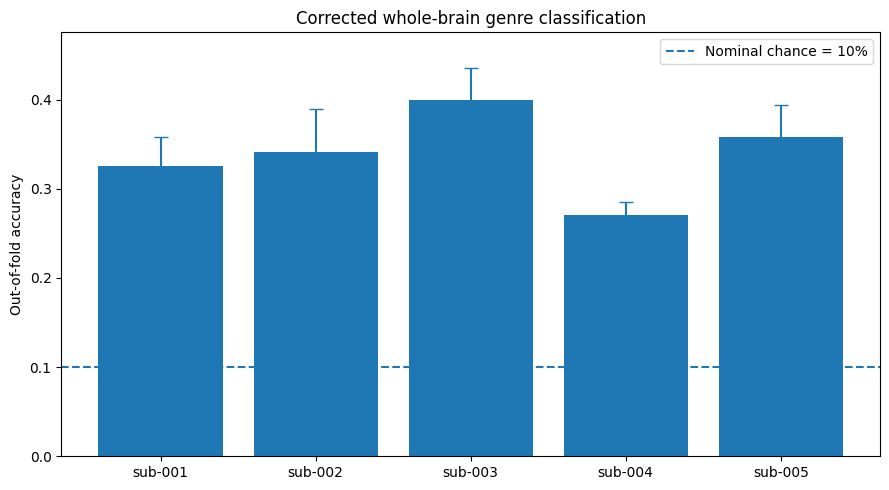

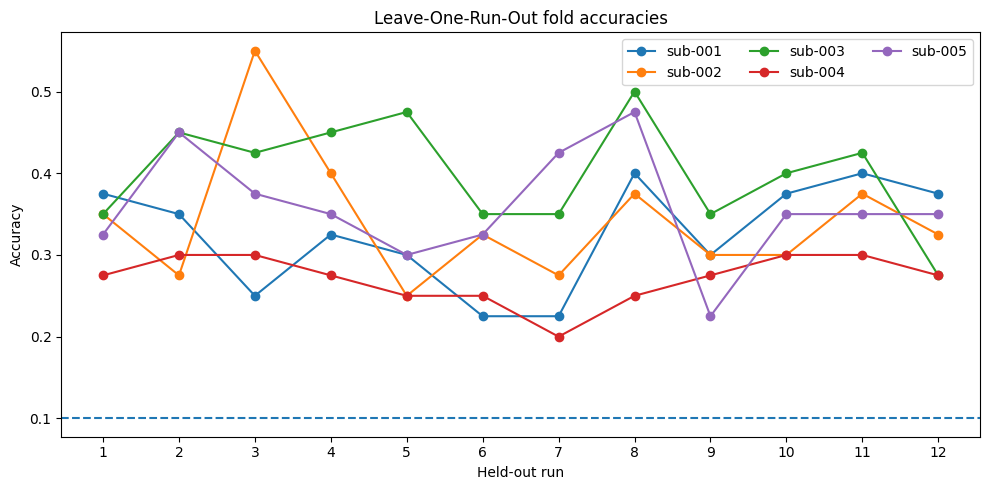

In [10]:
# Subject-level accuracy
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(primary_summary_df))
acc = primary_summary_df["accuracy"].to_numpy()
lower = acc - primary_summary_df["run_bootstrap_ci_low"].to_numpy()
upper = primary_summary_df["run_bootstrap_ci_high"].to_numpy() - acc

ax.bar(x, acc)
ax.errorbar(x, acc, yerr=np.vstack([lower, upper]), fmt="none", capsize=5)
ax.axhline(0.10, linestyle="--", linewidth=1.5, label="Nominal chance = 10%")
ax.set_xticks(x)
ax.set_xticklabels(primary_summary_df["subject"])
ax.set_ylabel("Out-of-fold accuracy")
ax.set_title("Corrected whole-brain genre classification")
ax.set_ylim(0, max(0.30, float((acc + upper).max()) + 0.04))
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_ROOT / "primary_accuracy_by_subject.png", dpi=200)
plt.show()

# Fold-level accuracy
fig, ax = plt.subplots(figsize=(10, 5))
for sid, subject_folds in fold_results_df.groupby("subject"):
    ax.plot(
        subject_folds["held_out_run"],
        subject_folds["accuracy"],
        marker="o",
        label=sid,
    )
ax.axhline(0.10, linestyle="--", linewidth=1.5)
ax.set_xlabel("Held-out run")
ax.set_ylabel("Accuracy")
ax.set_title("Leave-One-Run-Out fold accuracies")
ax.set_xticks(range(1, 13))
ax.legend(ncol=3)
fig.tight_layout()
fig.savefig(OUTPUT_ROOT / "primary_fold_accuracies.png", dpi=200)
plt.show()

## 11. Confusion matrices and per-genre metrics

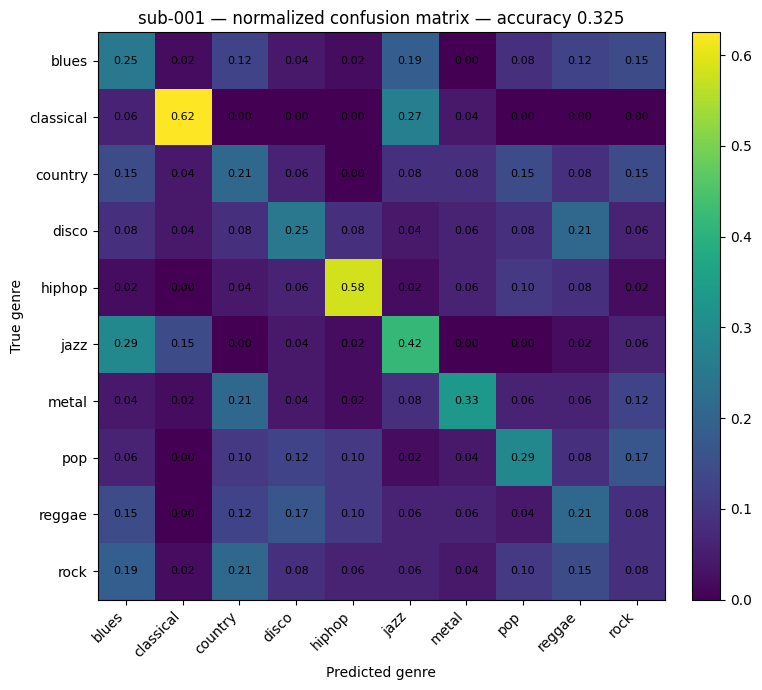

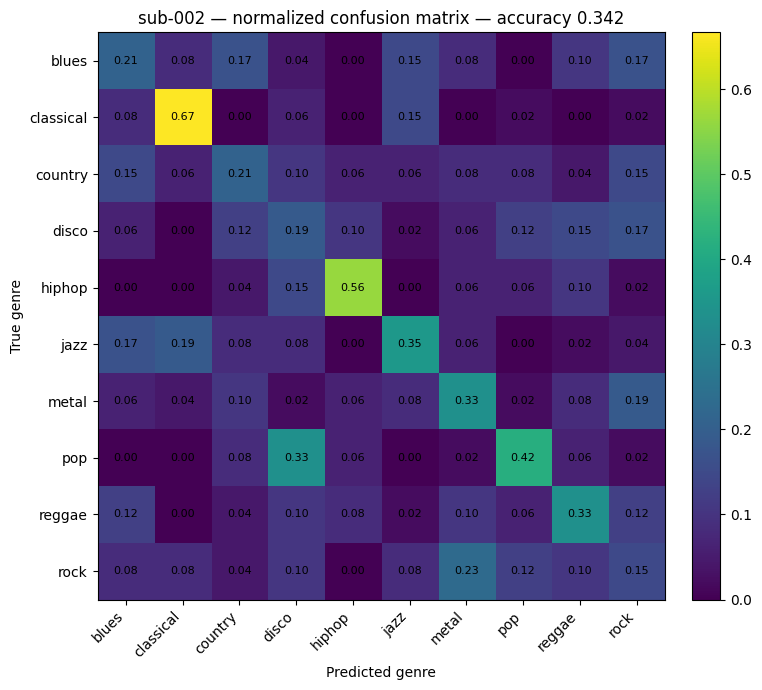

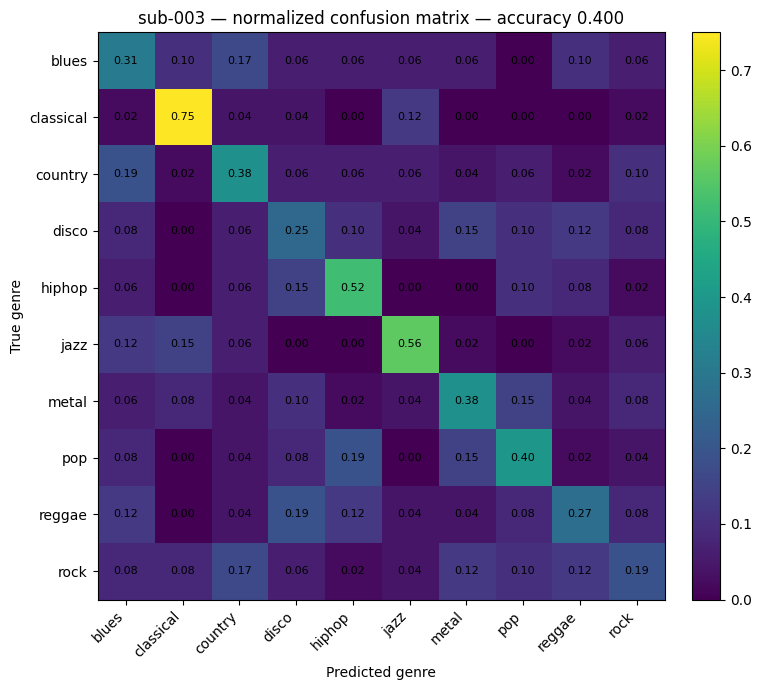

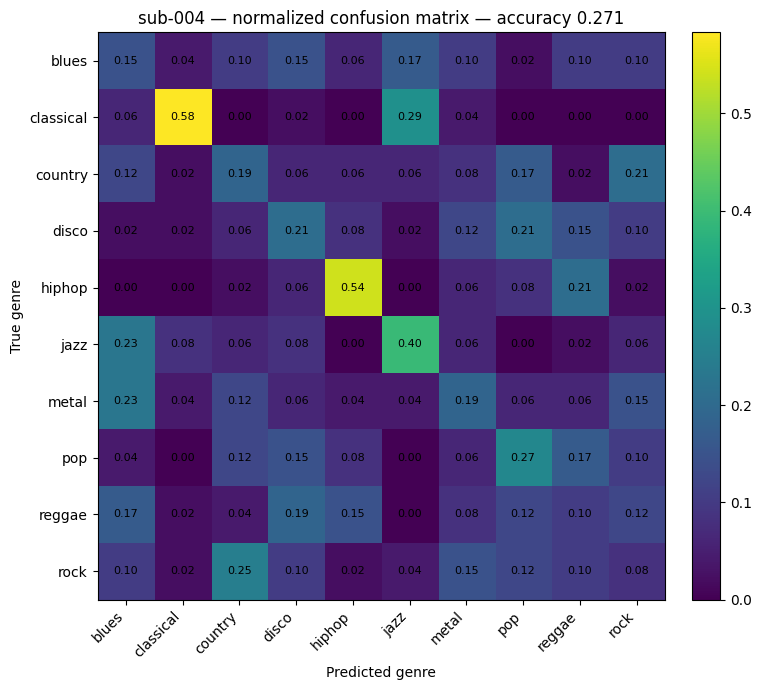

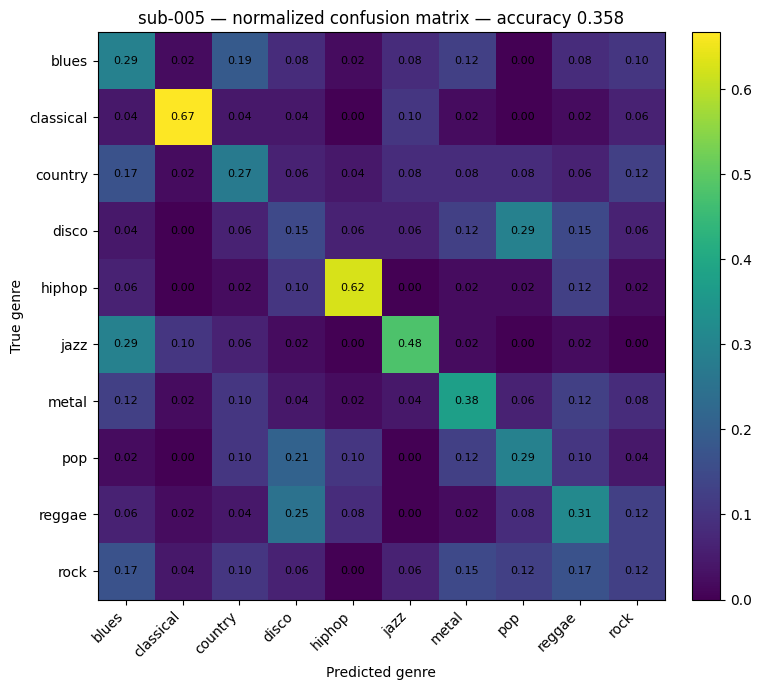

,precision,recall,f1_score
genre,,,
classical,0.670035,0.658333,0.661000
hiphop,0.565441,0.566667,0.565588
jazz,0.440929,0.441667,0.440022
pop,0.345562,0.333333,0.339092
metal,0.343408,0.320833,0.330035
country,0.247300,0.250000,0.248349
reggae,0.249943,0.245833,0.246872
blues,0.209527,0.241667,0.223727
disco,0.205755,0.208333,0.206485


In [11]:
GENRES = sorted(predictions_df["y_true"].unique())

classification_rows = []

for sid, subject_predictions in predictions_df.groupby("subject"):
    y_true = subject_predictions["y_true"].to_numpy()
    y_pred = subject_predictions["y_pred"].to_numpy()

    cm = confusion_matrix(y_true, y_pred, labels=GENRES, normalize="true")

    fig, ax = plt.subplots(figsize=(8, 7))
    image = ax.imshow(cm, vmin=0.0, vmax=max(0.30, float(np.nanmax(cm))))
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

    ax.set_xticks(np.arange(len(GENRES)))
    ax.set_yticks(np.arange(len(GENRES)))
    ax.set_xticklabels(GENRES, rotation=45, ha="right")
    ax.set_yticklabels(GENRES)
    ax.set_xlabel("Predicted genre")
    ax.set_ylabel("True genre")
    subject_acc = accuracy_score(y_true, y_pred)
    ax.set_title(f"{sid} — normalized confusion matrix — accuracy {subject_acc:.3f}")

    for i in range(len(GENRES)):
        for j in range(len(GENRES)):
            ax.text(j, i, f"{cm[i, j]:.2f}", ha="center", va="center", fontsize=8)

    fig.tight_layout()
    fig.savefig(OUTPUT_ROOT / f"{sid}_primary_confusion_matrix.png", dpi=200)
    plt.show()

    report = classification_report(
        y_true,
        y_pred,
        labels=GENRES,
        output_dict=True,
        zero_division=0,
    )
    for genre in GENRES:
        classification_rows.append(
            {
                "subject": sid,
                "genre": genre,
                "precision": report[genre]["precision"],
                "recall": report[genre]["recall"],
                "f1_score": report[genre]["f1-score"],
                "support": report[genre]["support"],
            }
        )

per_genre_df = pd.DataFrame(classification_rows)
per_genre_df.to_csv(OUTPUT_ROOT / "primary_per_genre_metrics.csv", index=False)

display(
    per_genre_df.groupby("genre")[["precision", "recall", "f1_score"]]
    .mean()
    .sort_values("f1_score", ascending=False)
)

## 12. Sanity baselines

Aa a nominal 10% line is not enough. The following checks help reveal accidental structure:

1. **Most-frequent classifier** evaluated with the same held-out runs.
2. **Shuffled-label permutation test** in Section 13.
3. Inspect whether all runs and genres have the expected counts.

In [19]:
from sklearn.dummy import DummyClassifier

def evaluate_dummy_subject(subject_id: str) -> Dict:
    X, y, runs, _ = load_cached_subject(subject_id, mmap=True)
    logo = LeaveOneGroupOut()
    pred = np.empty(y.shape, dtype=y.dtype)

    for train_idx, test_idx in logo.split(X, y, groups=runs):
        dummy = DummyClassifier(strategy="most_frequent")
        # One constant column is sufficient; the dummy model ignores fMRI features.
        dummy.fit(np.zeros((len(train_idx), 1)), y[train_idx])
        pred[test_idx] = dummy.predict(np.zeros((len(test_idx), 1)))

    return {
        "subject": subject_id,
        "dummy_accuracy": accuracy_score(y, pred),
        "dummy_balanced_accuracy": balanced_accuracy_score(y, pred),
    }


dummy_df = pd.DataFrame([evaluate_dummy_subject(sid) for sid in SUBJECT_IDS])
display(dummy_df)
dummy_df.to_csv(OUTPUT_ROOT / "dummy_baseline.csv", index=False)

,subject,dummy_accuracy,dummy_balanced_accuracy
0,sub-001,0.1,0.1
1,sub-002,0.1,0.1
2,sub-003,0.1,0.1
3,sub-004,0.1,0.1
4,sub-005,0.1,0.1


## 13. Group-constrained permutation tests 

This section permutes genre labels **within each run** and repeats the complete cross-validated pipeline. It therefore preserves:

- the 12-run grouping,
- the number of examples in each run,
- and the genre counts within each run.

`N_PERMUTATIONS = 1000` gives a minimum attainable empirical p-value of approximately `0.001`.

This is computationally expensive. First confirm that Sections 1–12 run correctly. Then set:

```python
RUN_PERMUTATION_TESTS = True
```

and rerun this section. Keep `n_jobs=1` unless the machine has enough memory to hold multiple copies of a subject's feature matrix.

Permutation test: sub-001


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:  3.2min
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed: 12.8min
[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed: 29.9min
[Parallel(n_jobs=1)]: Done 799 tasks      | elapsed: 52.3min
[Parallel(n_jobs=1)]: Done 1000 out of 1000 | elapsed: 65.2min finished


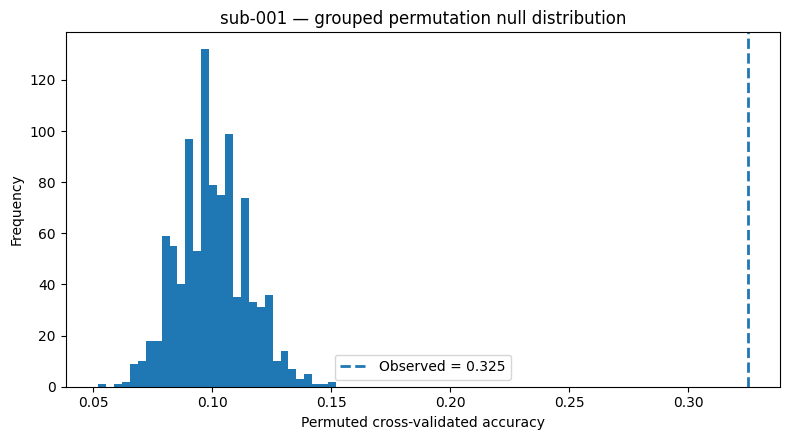

Permutation test: sub-002


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:  2.9min
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed: 12.0min
[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed: 28.0min
[Parallel(n_jobs=1)]: Done 799 tasks      | elapsed: 50.0min
[Parallel(n_jobs=1)]: Done 1000 out of 1000 | elapsed: 62.9min finished


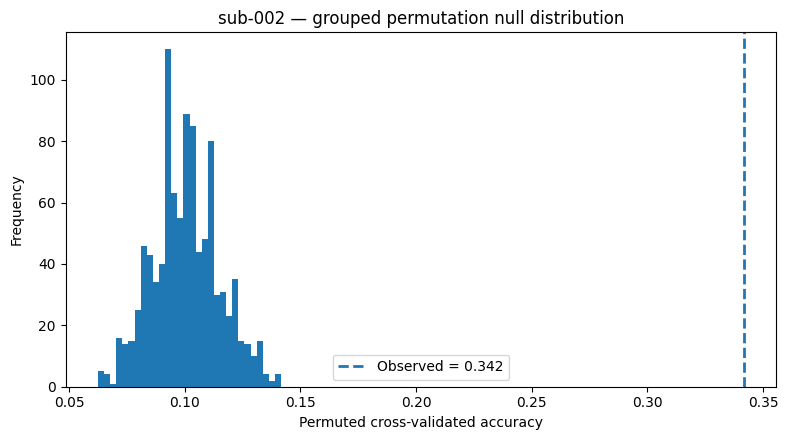

Permutation test: sub-003


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:  4.1min
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed: 14.8min
[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed: 31.9min
[Parallel(n_jobs=1)]: Done 799 tasks      | elapsed: 56.0min
[Parallel(n_jobs=1)]: Done 1000 out of 1000 | elapsed: 70.0min finished


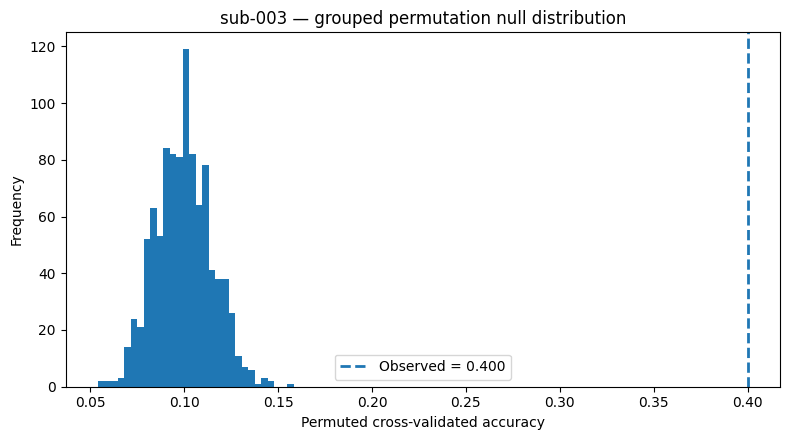

Permutation test: sub-004


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:  3.3min
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed: 13.2min
[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed: 29.8min
[Parallel(n_jobs=1)]: Done 799 tasks      | elapsed: 52.7min
[Parallel(n_jobs=1)]: Done 1000 out of 1000 | elapsed: 68.2min finished


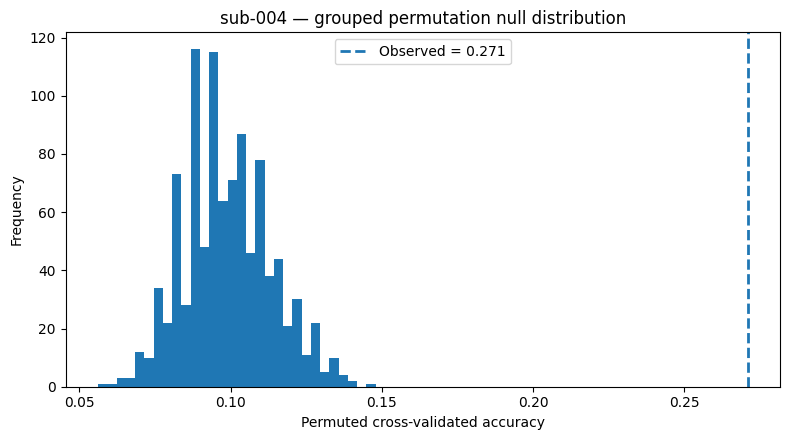

Permutation test: sub-005


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:  2.9min
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed: 11.7min
[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed: 28.4min
[Parallel(n_jobs=1)]: Done 799 tasks      | elapsed: 49.9min
[Parallel(n_jobs=1)]: Done 1000 out of 1000 | elapsed: 66.8min finished


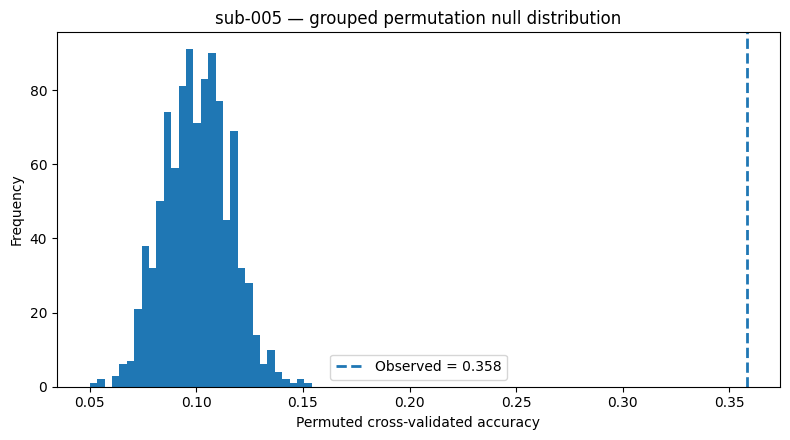

,subject,observed_cv_accuracy,permutation_mean,permutation_std,p_value,n_permutations,elapsed_minutes
0,sub-001,0.325000,0.100013,0.014699,0.000999,1000,65.305252
1,sub-002,0.341667,0.100523,0.014393,0.000999,1000,62.947540
2,sub-003,0.400000,0.099719,0.014859,0.000999,1000,70.086286
3,sub-004,0.270833,0.098865,0.014382,0.000999,1000,68.305352
4,sub-005,0.358333,0.100354,0.015478,0.000999,1000,66.859172


In [18]:
permutation_rows = []

if RUN_PERMUTATION_TESTS:
    for sid in SUBJECT_IDS:
        print(f"Permutation test: {sid}")
        X, y, runs, _ = load_cached_subject(sid, mmap=True)
        model = make_primary_pipeline()
        logo = LeaveOneGroupOut()

        started = time.time()
        score, permutation_scores, p_value = permutation_test_score(
            estimator=model,
            X=X,
            y=y,
            groups=runs,               # constrains label permutation within each run
            cv=logo,
            n_permutations=N_PERMUTATIONS,
            scoring="accuracy",
            n_jobs=1,
            random_state=RANDOM_SEED,
            verbose=1,
        )

        np.save(
            OUTPUT_ROOT / f"{sid}_permutation_scores_{N_PERMUTATIONS}.npy",
            permutation_scores,
        )

        permutation_rows.append(
            {
                "subject": sid,
                "observed_cv_accuracy": score,
                "permutation_mean": float(np.mean(permutation_scores)),
                "permutation_std": float(np.std(permutation_scores)),
                "p_value": p_value,
                "n_permutations": N_PERMUTATIONS,
                "elapsed_minutes": (time.time() - started) / 60,
            }
        )

        fig, ax = plt.subplots(figsize=(8, 4.5))
        ax.hist(permutation_scores, bins=30)
        ax.axvline(score, linestyle="--", linewidth=2, label=f"Observed = {score:.3f}")
        ax.set_xlabel("Permuted cross-validated accuracy")
        ax.set_ylabel("Frequency")
        ax.set_title(f"{sid} — grouped permutation null distribution")
        ax.legend()
        fig.tight_layout()
        fig.savefig(OUTPUT_ROOT / f"{sid}_permutation_test.png", dpi=200)
        plt.show()

        del X
        gc.collect()

    permutation_df = pd.DataFrame(permutation_rows)
    display(permutation_df)
    permutation_df.to_csv(OUTPUT_ROOT / "primary_permutation_tests.csv", index=False)
else:
    print(
        "Permutation tests were not run. "
        "Set RUN_PERMUTATION_TESTS = True after validating the primary pipeline."
    )

## 14. (Optional) nested model comparison

The fixed primary model is the cleanest headline baseline because its settings were not chosen from the newly reported scores.

This optional analysis estimates the performance of a tuned SVM without reusing the outer test run for model selection:

- Outer loop: Leave-One-Run-Out
- Inner loop: GroupKFold on the 11 training runs
- Tuned parameters: voxel count, kernel, and `C`
- The held-out outer run remains untouched until the inner search has selected a model

!! This may take several hours. !!

In [14]:
NESTED_PARAM_GRID = [
    {
        "select__k": [500, 1300, 3000],
        "svm__kernel": ["linear"],
        "svm__C": [0.1, 1.0, 10.0],
    },
    {
        "select__k": [500, 1300],
        "svm__kernel": ["rbf"],
        "svm__C": [0.1, 1.0, 10.0],
        "svm__gamma": ["scale"],
    },
]


def nested_evaluate_subject(subject_id: str):
    X, y, runs, metadata = load_cached_subject(subject_id, mmap=True)
    outer = LeaveOneGroupOut()

    y_pred = np.empty(y.shape, dtype=y.dtype)
    outer_rows = []

    base_pipeline = make_primary_pipeline()

    for outer_fold, (train_idx, test_idx) in enumerate(
        outer.split(X, y, groups=runs), start=1
    ):
        train_groups = runs[train_idx]
        inner = GroupKFold(n_splits=5)

        search = GridSearchCV(
            estimator=base_pipeline,
            param_grid=NESTED_PARAM_GRID,
            scoring="accuracy",
            cv=inner,
            n_jobs=NESTED_N_JOBS,
            refit=True,
            return_train_score=False,
            error_score="raise",
        )
        search.fit(X[train_idx], y[train_idx], groups=train_groups)
        fold_pred = search.predict(X[test_idx])
        y_pred[test_idx] = fold_pred

        row = {
            "subject": subject_id,
            "outer_fold": outer_fold,
            "held_out_run": int(np.unique(runs[test_idx])[0]),
            "outer_accuracy": accuracy_score(y[test_idx], fold_pred),
            "inner_best_score": search.best_score_,
        }
        row.update({f"best_{key}": value for key, value in search.best_params_.items()})
        outer_rows.append(row)

    summary = {
        "subject": subject_id,
        "nested_accuracy": accuracy_score(y, y_pred),
        "nested_balanced_accuracy": balanced_accuracy_score(y, y_pred),
    }
    prediction_df = metadata.copy()
    prediction_df["y_true"] = y
    prediction_df["y_pred_nested"] = y_pred
    prediction_df["correct_nested"] = y == y_pred

    return summary, pd.DataFrame(outer_rows), prediction_df


if RUN_NESTED_CV:
    nested_summaries = []
    nested_folds = []
    nested_predictions = []

    for sid in SUBJECT_IDS:
        print("Nested CV:", sid)
        summary, folds, preds = nested_evaluate_subject(sid)
        nested_summaries.append(summary)
        nested_folds.append(folds)
        nested_predictions.append(preds)

    nested_summary_df = pd.DataFrame(nested_summaries)
    nested_fold_df = pd.concat(nested_folds, ignore_index=True)
    nested_prediction_df = pd.concat(nested_predictions, ignore_index=True)

    display(nested_summary_df)
    display(nested_fold_df)

    nested_summary_df.to_csv(OUTPUT_ROOT / "nested_subject_summary.csv", index=False)
    nested_fold_df.to_csv(OUTPUT_ROOT / "nested_outer_fold_details.csv", index=False)
    nested_prediction_df.to_csv(
        OUTPUT_ROOT / "nested_out_of_fold_predictions.csv", index=False
    )
else:
    print("Nested CV was not run. Set RUN_NESTED_CV = True to enable it.")

Nested CV was not run. Set RUN_NESTED_CV = True to enable it.


## 15. Reproducibility record

This cell saves the exact methodological settings used in the notebook.
(Keep this JSON file with the final report and figures.)

In [22]:
analysis_record = {
    "alignment": asdict(CACHE_CONFIG),
    "subjects": SUBJECT_IDS,
    "feature_definition": (
        "Mean of 10 derivative response volumes per retained 15-second clip; "
        "onset-0 repeated event removed from every training run; no HRF-delay tuning."
    ),
    "primary_model": {
        "variance_threshold": 0.0,
        "feature_selection": "SelectKBest(f_classif)",
        "k": PRIMARY_K,
        "scaling": "StandardScaler fitted inside each CV fold",
        "classifier": "SVC",
        "kernel": PRIMARY_KERNEL,
        "C": PRIMARY_C,
        "gamma": "scale",
    },
    "outer_validation": "LeaveOneGroupOut with run number as group",
    "random_seed": RANDOM_SEED,
    "software": {
        "python": sys.version,
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "scikit_learn": sklearn_version,
    },
    "permutation_tests_requested": RUN_PERMUTATION_TESTS,
    "n_permutations": N_PERMUTATIONS if RUN_PERMUTATION_TESTS else 0,
    "nested_cv_requested": RUN_NESTED_CV,
}

record_path = OUTPUT_ROOT / "analysis_configuration.json"
record_path.write_text(json.dumps(analysis_record, indent=2))
print("Saved:", record_path)

Saved: /Users/manognya/Downloads/FMRI_Classification/outputs_corrected_phase1/analysis_configuration.json
